In [1]:
from src.dataloader import LoadForecastDataLoader
from pathlib import Path
import torch

In [2]:
# ============================================================
# Model save directory
# ============================================================

SAVE_DIR = Path("models/24_lookback_24_horizon")

SAVE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

BEST_MODEL_PATH = SAVE_DIR / "best_lstm.pt"


In [3]:
loader = LoadForecastDataLoader(

    csv_path="Data/T1.csv",

    datetime_col="Date/Time",
    datetime_format="%d %m %Y %H:%M",
    features=[
        "Wind Speed (m/s)",
        "Theoretical_Power_Curve (KWh)",
        "Wind Direction (°)",

    ],

    target="LV ActivePower (kW)",

    lookback=24,

    horizon=24,

    expected_frequency="1h"
)

In [4]:
df = loader.get_dataframe()

In [5]:
loader.summary()


DATASET SUMMARY
File:       Data\T1.csv
Rows:       50530
Columns:    5
Datetime:   Date/Time
Features:   ['Wind Speed (m/s)', 'Theoretical_Power_Curve (KWh)', 'Wind Direction (°)']
Target:     ['LV ActivePower (kW)']
Lookback:   24
Horizon:    24
Frequency:  1h
Start:      2018-01-01 00:00:00
End:        2018-12-31 23:50:00

Abnormalities:
- time_gaps: {'count': 50528, 'examples': {1: Timedelta('0 days 00:10:00'), 2: Timedelta('0 days 00:10:00'), 3: Timedelta('0 days 00:10:00'), 4: Timedelta('0 days 00:10:00'), 5: Timedelta('0 days 00:10:00'), 6: Timedelta('0 days 00:10:00'), 7: Timedelta('0 days 00:10:00'), 8: Timedelta('0 days 00:10:00'), 9: Timedelta('0 days 00:10:00'), 10: Timedelta('0 days 00:10:00')}}
- numeric_abnormalities: {'LV ActivePower (kW)': {'negative_values': 57}}



In [6]:
df

,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
0,2018-01-01 00:00:00,380.047791,5.311336,416.328908,259.994904
1,2018-01-01 00:10:00,453.769196,5.672167,519.917511,268.641113
2,2018-01-01 00:20:00,306.376587,5.216037,390.900016,272.564789
3,2018-01-01 00:30:00,419.645905,5.659674,516.127569,271.258087
4,2018-01-01 00:40:00,380.650696,5.577941,491.702972,265.674286
...,...,...,...,...,...
50525,2018-12-31 23:10:00,2963.980957,11.404030,3397.190793,80.502724
50526,2018-12-31 23:20:00,1684.353027,7.332648,1173.055771,84.062599
50527,2018-12-31 23:30:00,2201.106934,8.435358,1788.284755,84.742500
50528,2018-12-31 23:40:00,2515.694092,9.421366,2418.382503,84.297913


### Sperating data for test and train 
train 70% of data -> total 70%
validate 70-85% of the data -> total 15%
test 85-100% of data -> total 15% 

In [7]:

n = len(df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

### Data normalization [Scaling]

In [8]:
from sklearn.preprocessing import StandardScaler


features = loader.features
target = loader.target


feature_scaler = StandardScaler()
target_scaler = StandardScaler()


# Fit ONLY on training data
feature_scaler.fit(
    train_df[features]
)

target_scaler.fit(
    train_df[target]
)


# Transform all datasets
train_features = feature_scaler.transform(
    train_df[features]
)

val_features = feature_scaler.transform(
    val_df[features]
)

test_features = feature_scaler.transform(
    test_df[features]
)


train_target = target_scaler.transform(
    train_df[target]
)

val_target = target_scaler.transform(
    val_df[target]
)

test_target = target_scaler.transform(
    test_df[target]
)

In [9]:
import torch
from torch.utils.data import Dataset


class LSTMDataset(Dataset):

    def __init__(
        self,
        features,
        target,
        lookback,
        horizon
    ):

        self.features = features
        self.target = target

        self.lookback = lookback
        self.horizon = horizon

    def __len__(self):

        return (
            len(self.features)
            - self.lookback
            - self.horizon
            + 1
        )

    def __getitem__(self, index):

        X = self.features[
            index:
            index + self.lookback
        ]

        y = self.target[
            index + self.lookback:
            index + self.lookback + self.horizon
        ]

        X = torch.tensor(
            X,
            dtype=torch.float32
        )

        y = torch.tensor(
            y,
            dtype=torch.float32
        )

        return X, y

In [10]:
train_dataset = LSTMDataset(
    train_features,
    train_target,
    lookback=loader.lookback,
    horizon=loader.horizon
)

val_dataset = LSTMDataset(
    val_features,
    val_target,
    lookback=loader.lookback,
    horizon=loader.horizon
)

test_dataset = LSTMDataset(
    test_features,
    test_target,
    lookback=loader.lookback,
    horizon=loader.horizon
)

In [11]:
from torch.utils.data import DataLoader


BATCH_SIZE = 64


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [12]:
X, y = next(iter(train_loader))

print("X:", X.shape)
print("y:", y.shape)

X: torch.Size([64, 24, 3])
y: torch.Size([64, 24, 1])


In [13]:
from src.models.lstm import LSTMForecast

INPUT_SIZE = len(loader.features)

model = LSTMForecast(
    input_size=INPUT_SIZE,
    hidden_size=128,
    num_layers=2,
    horizon=loader.horizon,
    dropout=0.2
)

In [14]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model = model.to(device)

print(device)

cpu


In [15]:
from torch import nn
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [16]:
def train_one_epoch(
    model,
    dataloader,
    criterion,
    optimizer,
    device
):

    model.train()

    total_loss = 0.0

    for X, y in dataloader:

        X = X.to(device)
        y = y.to(device)

        # Clear gradients
        optimizer.zero_grad()

        # Forward pass
        prediction = model(X)

        # Calculate loss
        loss = criterion(
            prediction,
            y
        )

        # Backpropagation
        loss.backward()

        # Update model
        optimizer.step()

        total_loss += loss.item()

    return (
        total_loss / len(dataloader)
    )

In [17]:
def validate(
    model,
    dataloader,
    criterion,
    device
):

    model.eval()

    total_loss = 0.0

    with torch.no_grad():

        for X, y in dataloader:

            X = X.to(device)
            y = y.to(device)

            prediction = model(X)

            loss = criterion(
                prediction,
                y
            )

            total_loss += loss.item()

    return (
        total_loss / len(dataloader)
    )

In [18]:

EPOCHS = 30

best_val_loss = float("inf")

train_losses = []
val_losses = []


for epoch in range(EPOCHS):

    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss = validate(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} "
        f"| Train: {train_loss:.5f} "
        f"| Val: {val_loss:.5f}"
    )

    # Save best model
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            BEST_MODEL_PATH
        )

        print(
            f"  -> Best model saved to: "
            f"{BEST_MODEL_PATH}"
        )

Epoch 01/30 | Train: 0.33498 | Val: 0.28544
  -> Best model saved to: models\24_lookback_24_horizon\best_lstm.pt
Epoch 02/30 | Train: 0.30842 | Val: 0.30679
Epoch 03/30 | Train: 0.30618 | Val: 0.29397
Epoch 04/30 | Train: 0.30312 | Val: 0.30068
Epoch 05/30 | Train: 0.29940 | Val: 0.29561
Epoch 06/30 | Train: 0.29346 | Val: 0.30503
Epoch 07/30 | Train: 0.28955 | Val: 0.34439
Epoch 08/30 | Train: 0.28413 | Val: 0.30984
Epoch 09/30 | Train: 0.27769 | Val: 0.32522
Epoch 10/30 | Train: 0.26886 | Val: 0.38973
Epoch 11/30 | Train: 0.25733 | Val: 0.37850
Epoch 12/30 | Train: 0.24319 | Val: 0.34798
Epoch 13/30 | Train: 0.23061 | Val: 0.43546
Epoch 14/30 | Train: 0.22052 | Val: 0.45592
Epoch 15/30 | Train: 0.20701 | Val: 0.48710
Epoch 16/30 | Train: 0.19267 | Val: 0.39728
Epoch 17/30 | Train: 0.18604 | Val: 0.49709
Epoch 18/30 | Train: 0.17169 | Val: 0.48567
Epoch 19/30 | Train: 0.16397 | Val: 0.46724
Epoch 20/30 | Train: 0.15900 | Val: 0.48773
Epoch 21/30 | Train: 0.14632 | Val: 0.51465
Epoch 2

### Loading model

In [19]:
model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=device
    )
)

model.eval()

LSTMForecast(
  (lstm): LSTM(3, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=128, out_features=24, bias=True)
)

### Testing the model

In [20]:
import numpy as np


predictions = []
actuals = []


with torch.no_grad():

    for X, y in test_loader:

        X = X.to(device)

        prediction = model(X)

        predictions.append(
            prediction.cpu().numpy()
        )

        actuals.append(
            y.numpy()
        )


predictions = np.concatenate(
    predictions,
    axis=0
)

actuals = np.concatenate(
    actuals,
    axis=0
)

print(
    "Predictions:",
    predictions.shape
)

print(
    "Actual:",
    actuals.shape
)

Predictions: (7533, 24, 1)
Actual: (7533, 24, 1)


In [21]:
predictions_original = (
    target_scaler
    .inverse_transform(
        predictions.reshape(-1, 1)
    )
    .reshape(predictions.shape)
)

actuals_original = (
    target_scaler
    .inverse_transform(
        actuals.reshape(-1, 1)
    )
    .reshape(actuals.shape)
)

In [22]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)


mae = mean_absolute_error(
    actuals_original.flatten(),
    predictions_original.flatten()
)

rmse = np.sqrt(
    mean_squared_error(
        actuals_original.flatten(),
        predictions_original.flatten()
    )
)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE:  505.00
RMSE: 727.81


Pred shape: (180792,)
Act shape: (180792,)


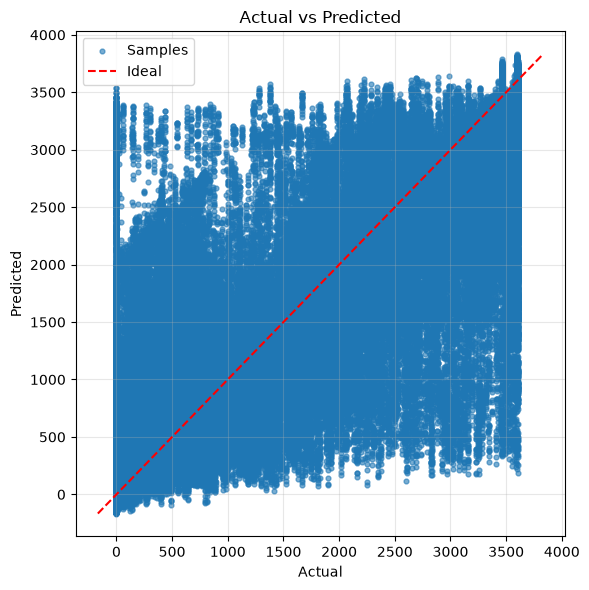

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# --- ensure shapes are compatible ---
pred = predictions_original.reshape(-1)
act = actuals_original.reshape(-1)

print("Pred shape:", pred.shape)
print("Act shape:", act.shape)

# --- scatter plot ---
plt.figure(figsize=(6,6))
plt.scatter(act, pred, s=12, alpha=0.6, label="Samples")

# --- 1:1 reference line ---
min_v = min(act.min(), pred.min())
max_v = max(act.max(), pred.max())
plt.plot([min_v, max_v], [min_v, max_v], 'r--', label="Ideal")

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


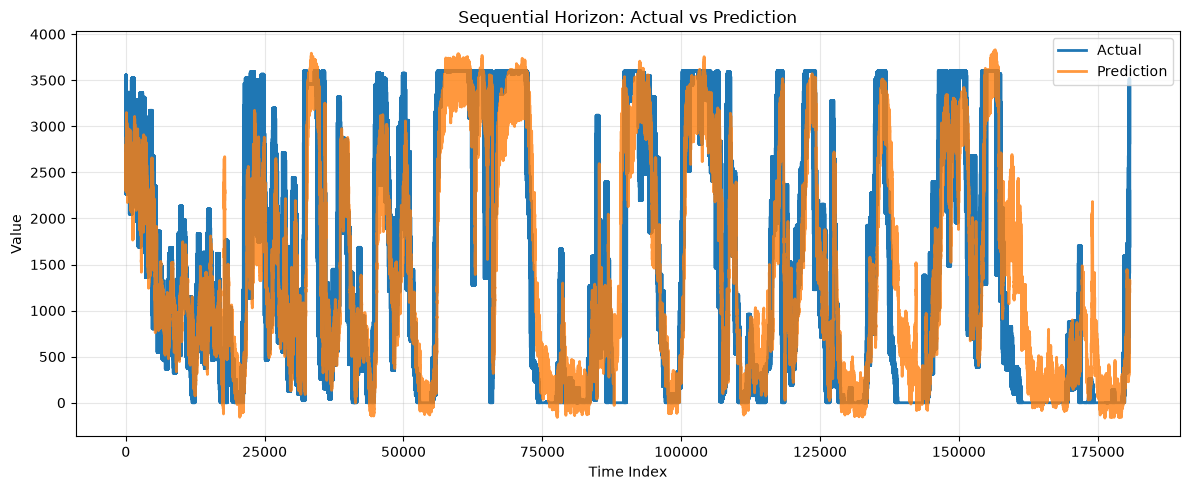

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Flatten in case they are (N,1)
pred = predictions_original.reshape(-1)
act = actuals_original.reshape(-1)

# Create a time index
t = np.arange(len(pred))

plt.figure(figsize=(12,5))
plt.plot(t, act, label="Actual", linewidth=2)
plt.plot(t, pred, label="Prediction", linewidth=2, alpha=0.8)

plt.title("Sequential Horizon: Actual vs Prediction")
plt.xlabel("Time Index")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


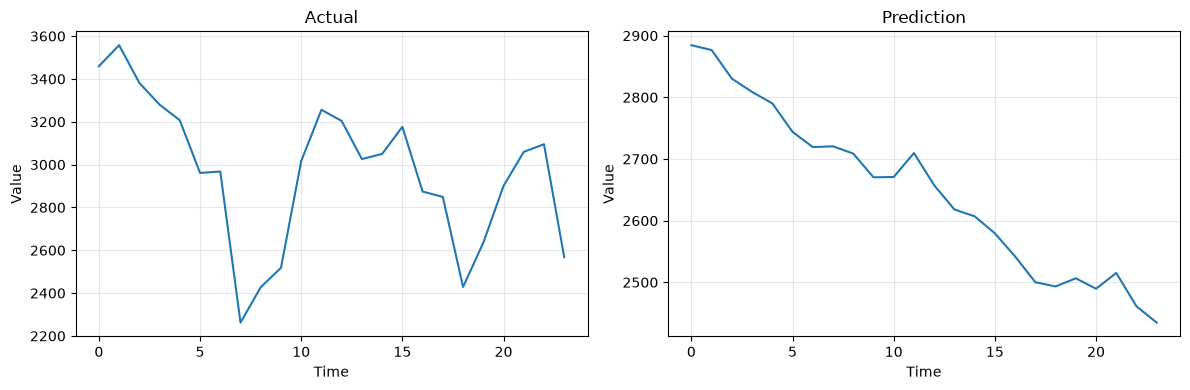

In [25]:
import matplotlib.pyplot as plt

# Select sample index
i = 3

actual = actuals_original[i, :, :]
pred   = predictions_original[i, :, :]

plt.figure(figsize=(12,4))

# --- Actual ---
plt.subplot(1, 2, 1)
plt.plot(actual)
plt.title("Actual")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)

# --- Prediction ---
plt.subplot(1, 2, 2)
plt.plot(pred)
plt.title("Prediction")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
